In [1]:
import numpy as np
from environment import custom_four_rooms
from helpers import get_inverted_model
from inverse_prediction import get_trajectories, get_step_distributions
from visualisations import show_distribution, show_distribution_comparison

# Prediction Tests

In [2]:
env = custom_four_rooms(isWindy=True)
goals = [
    (1, 1),
    (1, 9),
    (9, 1),
    (9, 9),
    (5, 3),
]

In [3]:
Q, P_hat, bellman_residual = get_inverted_model(env, goals, n_episodes=100000)

In [4]:
goal_index = 3
goal_state = goals[goal_index]
n_steps = 50
n_trajectories = 100000

model_trajectories = get_trajectories(
    env,
    Q,
    goal_index=goal_index,
    goal_state=goal_state,
    n_trajectories=n_trajectories,
    n_steps=n_steps,
    source="model",
    P_hat=P_hat,
)

environment_trajectories = get_trajectories(
    env,
    Q,
    goal_index=goal_index,
    goal_state=goal_state,
    n_trajectories=n_trajectories,
    n_steps=n_steps,
    source="environment",
)

model_distributions = get_step_distributions(
    model_trajectories
)

environment_distributions = get_step_distributions(
    environment_trajectories
)


In [10]:
visualised_steps = range(0, 10)

In [11]:
live_trajectory = environment_trajectories[50]

## Internal model only

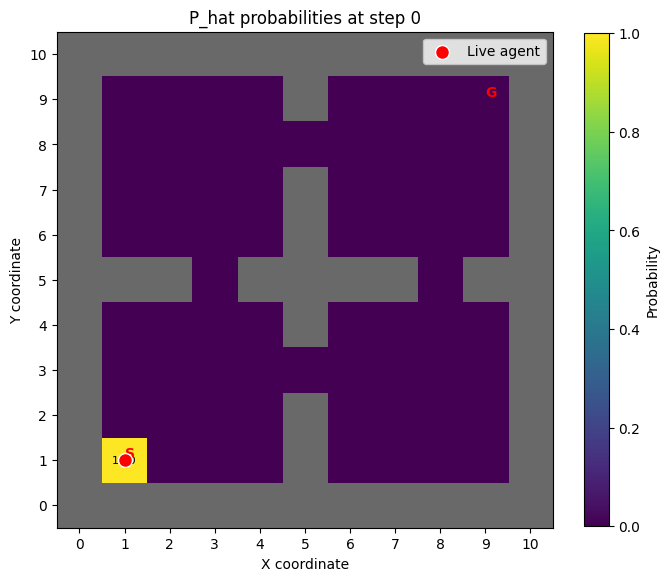

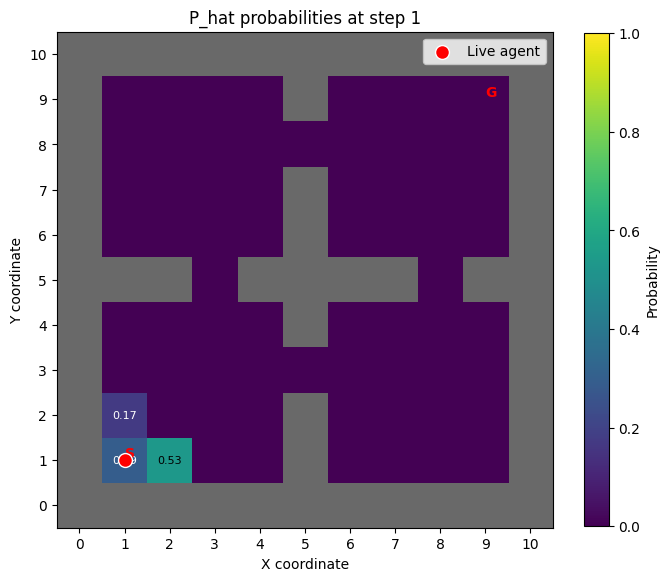

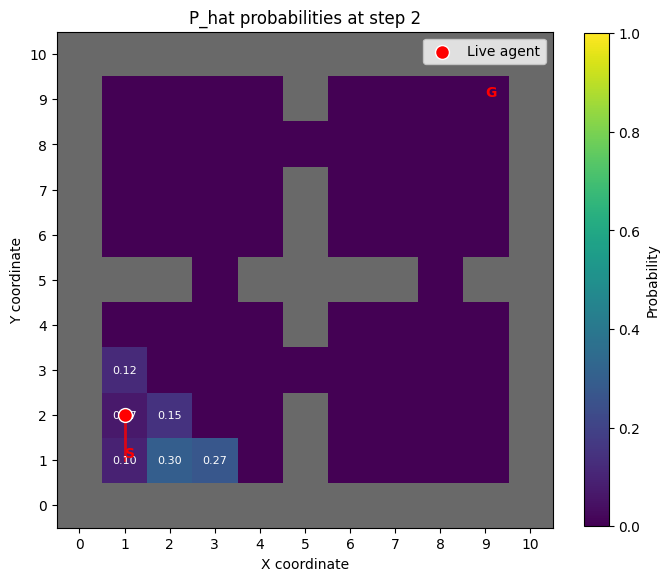

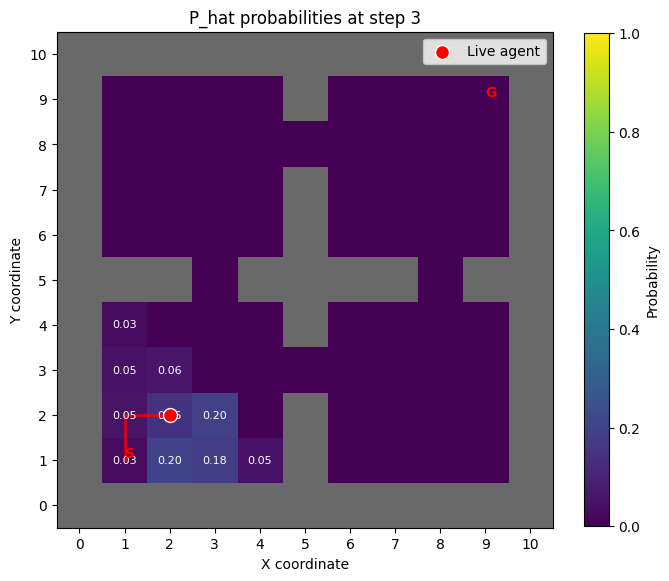

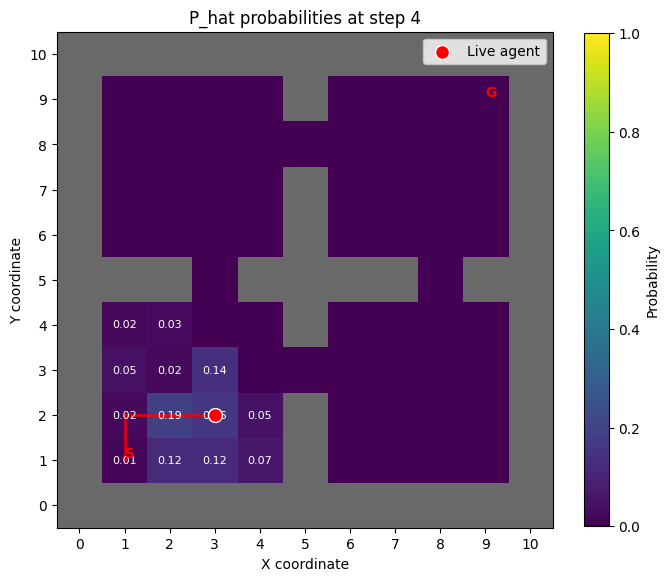

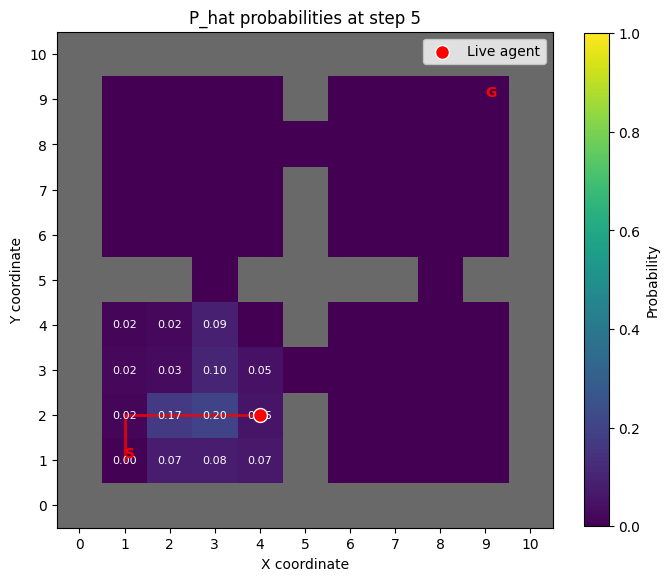

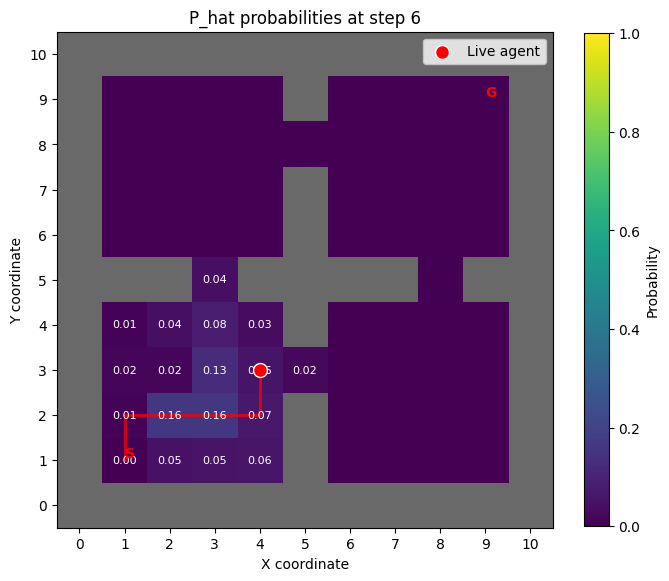

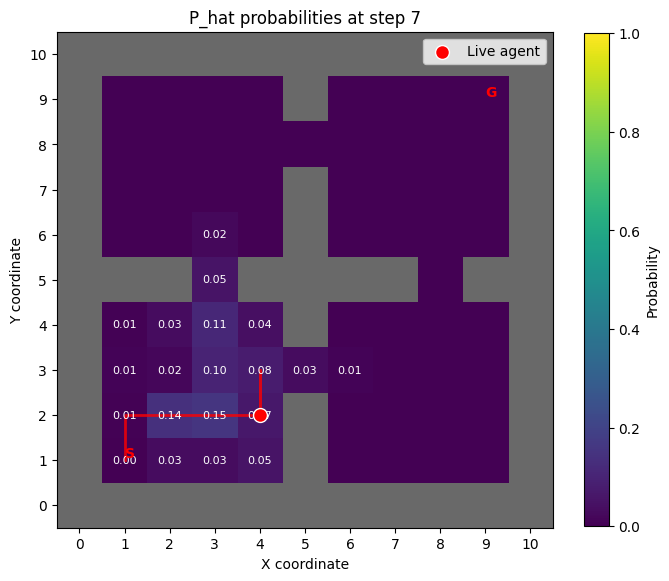

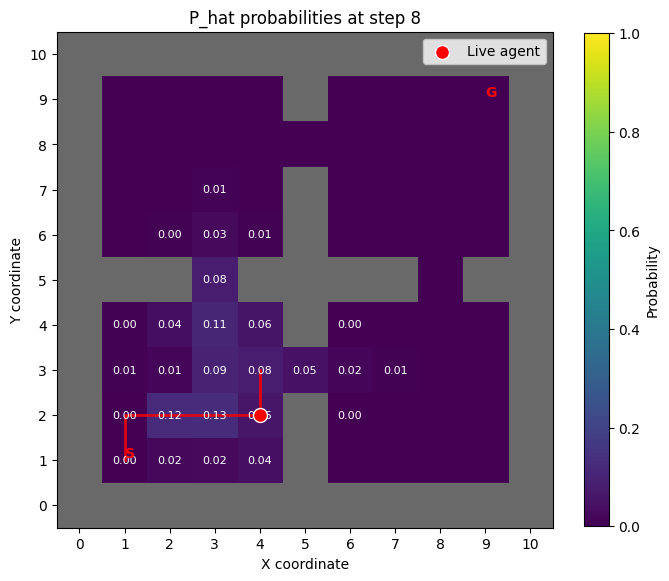

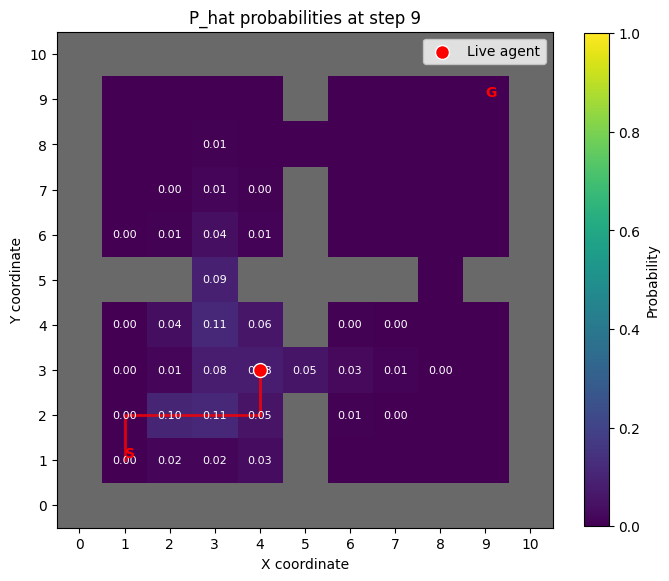

In [12]:
for s in visualised_steps:
  show_distribution(
      env,
      model_distributions,
      step=s,
      goal_state=goal_state,
      live_trajectory=live_trajectory,
  )

## Internal model compared to live agent trajectories

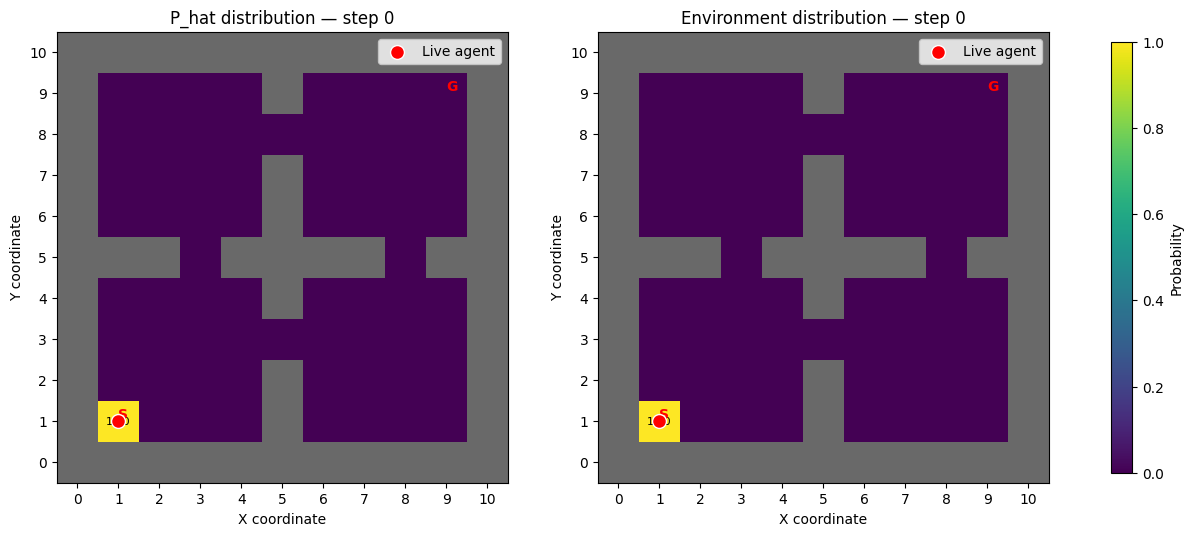

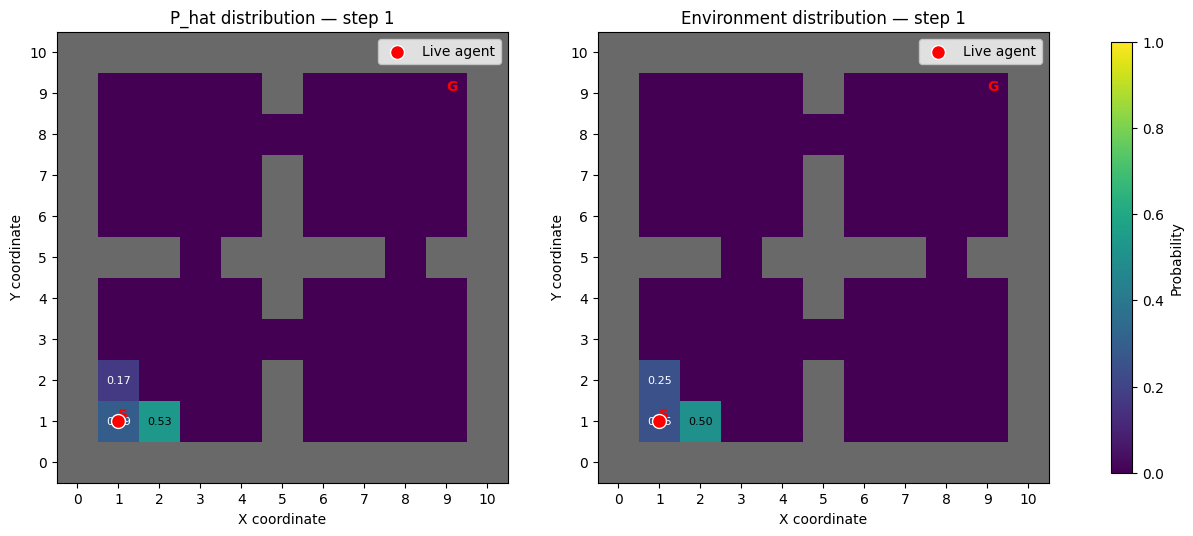

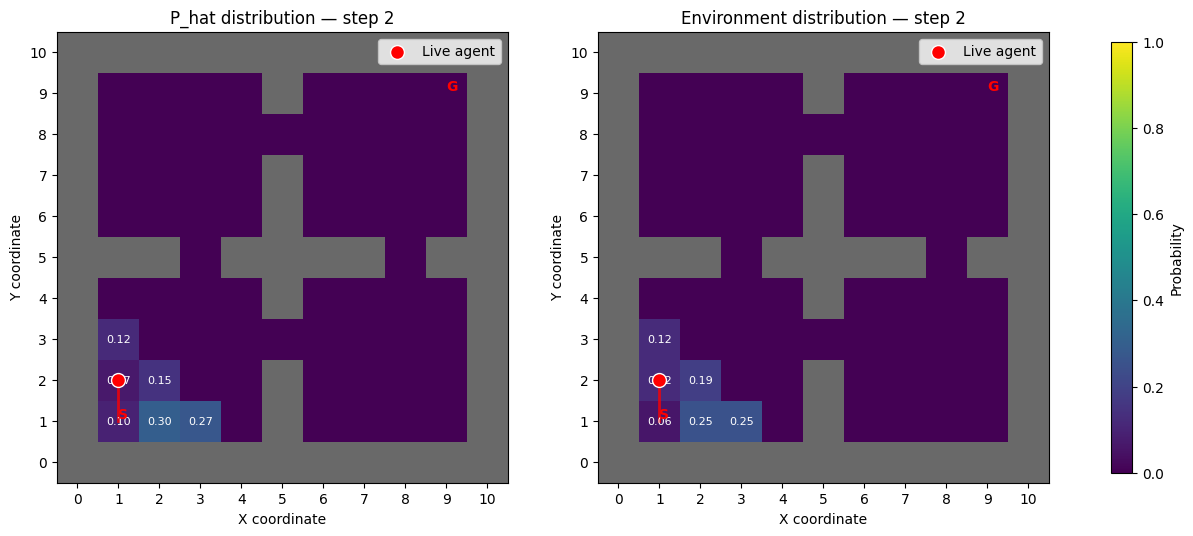

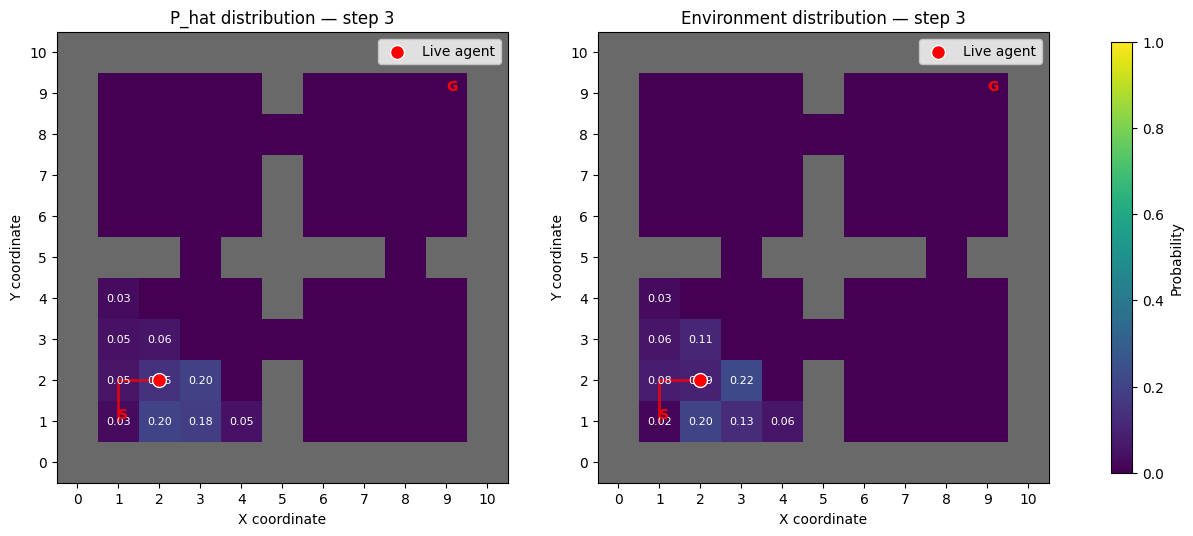

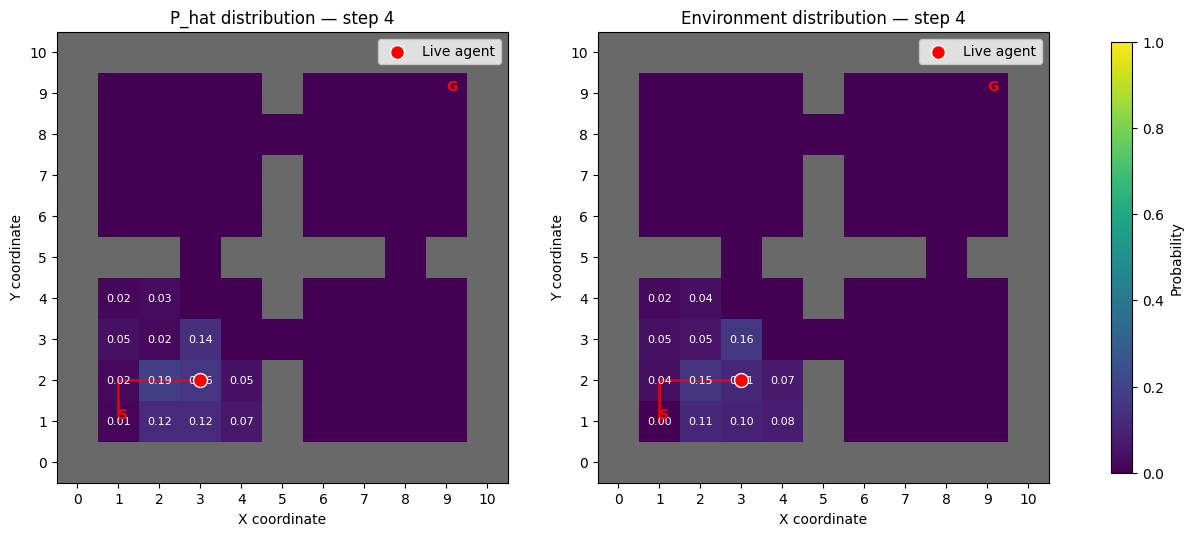

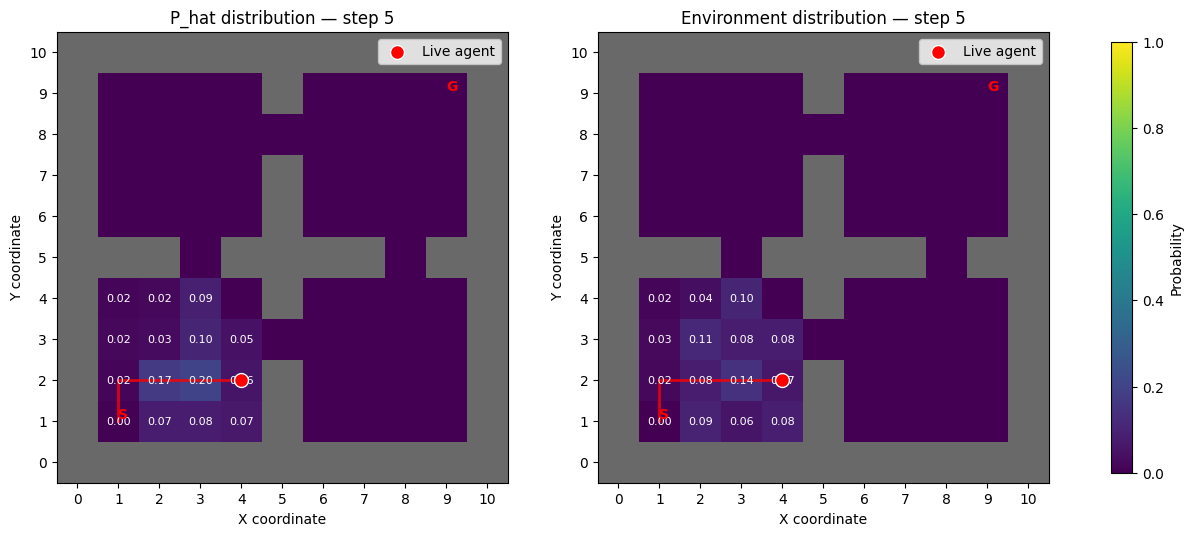

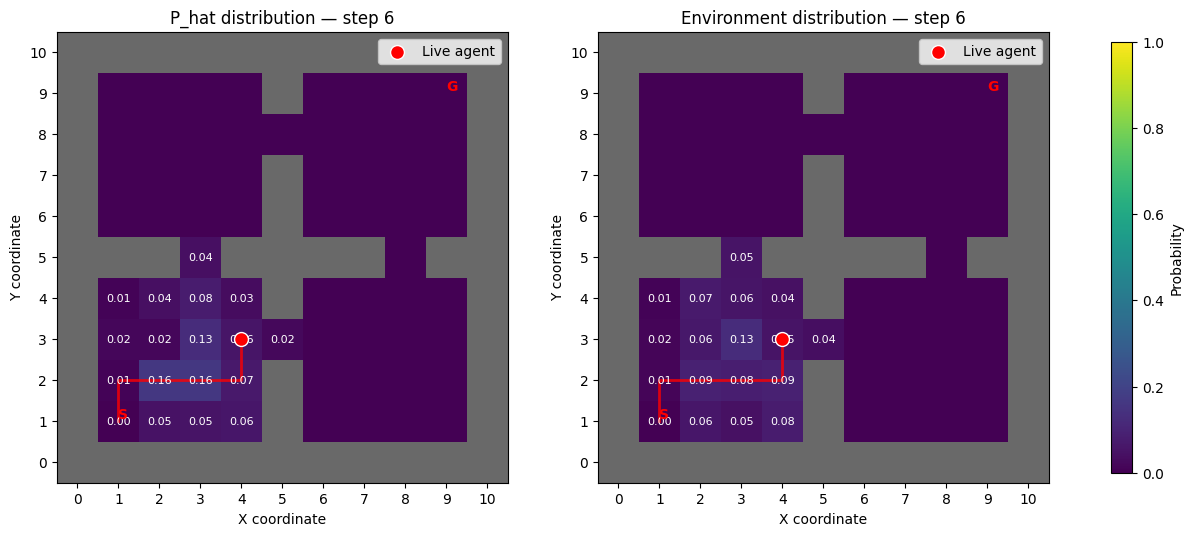

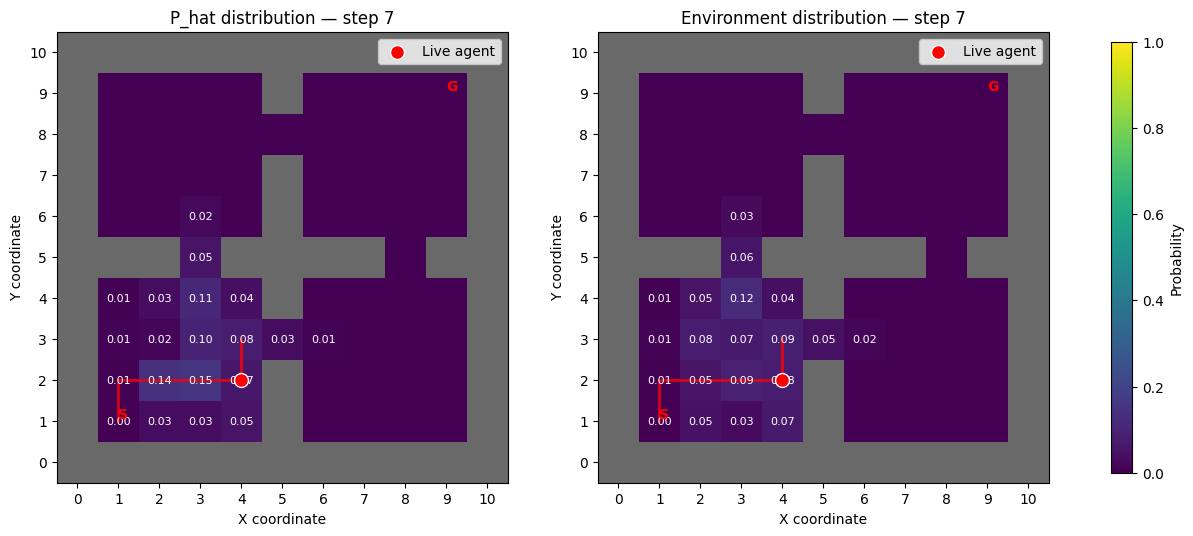

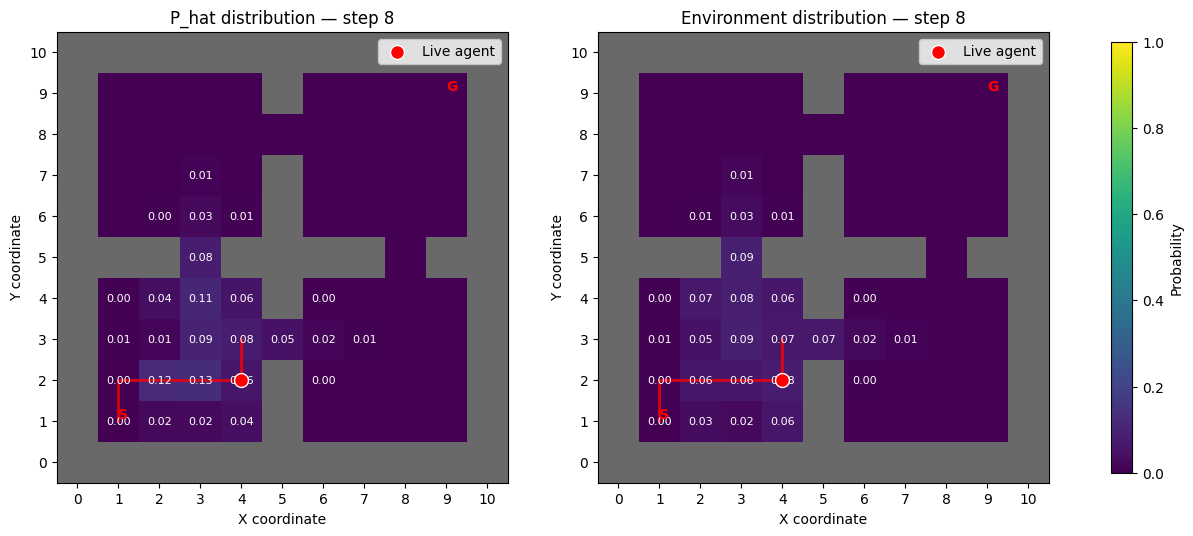

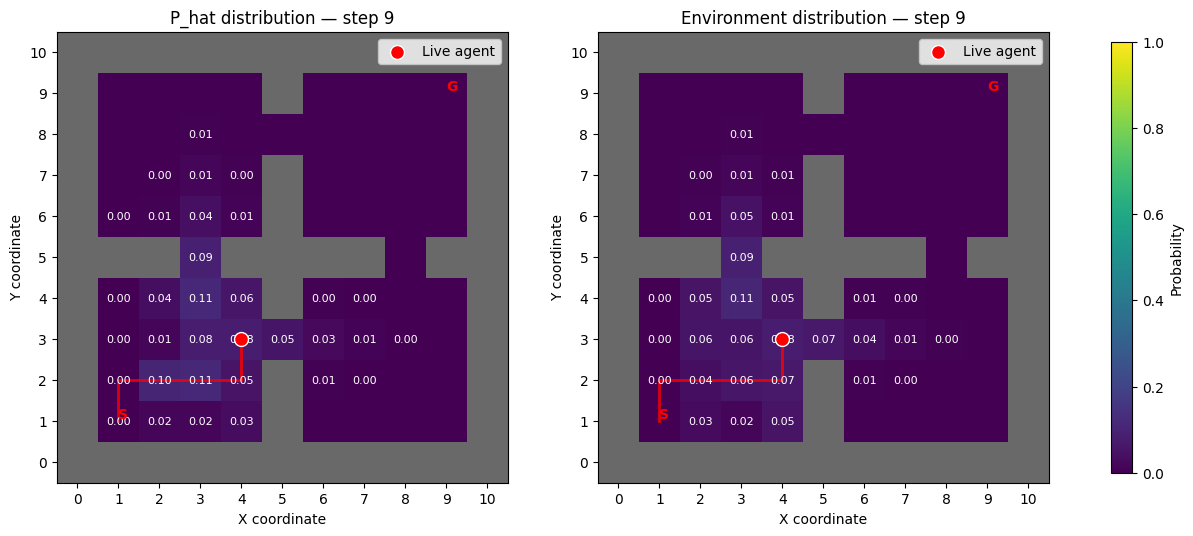

In [13]:
for s in visualised_steps:
  show_distribution_comparison(
    env,
    model_distributions,
    environment_distributions,
    step=s,
    goal_state=goal_state,
    live_trajectory=live_trajectory,
  )